# **PINN MODEL**

In this notebook, we will create the baseline model with no physics-informed loss function and a PINN with the modified loss function to account for the physics. We start off with our usual imports,

In [1]:
# PyTorch imports,
import torch # <-- PyTorch
from torch.nn import Linear
from torch.utils.data import Dataset, DataLoader # <-- Wrappers for the data.
from torch.optim import Adam
import torch.nn.functional as F
import torchvision
from torchinfo import summary

# Importing,
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import h5py
import sys

# Printing versions,
print("System Version:", sys.version)
print("PyTorch version", torch.__version__)
print("Torch Vision version", torchvision.__version__)
print("Numpy version", np.__version__)
print("Pandas version", pd.__version__)

System Version: 3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 13:17:27) [MSC v.1929 64 bit (AMD64)]
PyTorch version 2.6.0+cpu
Torch Vision version 0.21.0+cpu
Numpy version 1.26.4
Pandas version 2.2.2


### 1. Loading Data

In [11]:
class FlowDataset(Dataset):
    """Class container for the training data."""

    def __init__(self, split=None, data_tuple=None):
        """Loads, scales (using min-max) and converts the data into Tensors."""

        # Loading,
        data = np.load(f"data_{split}.npz")
        self.X, self.y, self.flags = data["X"], data["y"], data["flags"]
        self.n_samples = self.X.shape[0]

        # Converting to Tensors (float32 type),
        self.X = torch.from_numpy(self.X.astype(np.float32))
        self.y = torch.from_numpy(self.y.astype(np.float32))
        self.flags = torch.from_numpy(self.flags.astype(np.int64))

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx], self.flags[idx]
    
    def __len__(self):
        return self.n_samples

class Scaler():
    """Performs per feature min-max scaling. Note that we use the Tensor datatype (not NumPy arrays)."""

    def __init__(self):
        self.X_maxs, self.X_mins = None, None
        self.y_maxs, self.y_mins = None, None
        self.epsilon = 1e-8

    def fit(self, dataset):
        """Fit the scaler to the given data"""

        # Storing dataset,
        self.dataset = dataset

        # Computing the maximum and minimum values,
        X, y = dataset.X, dataset.y
        self.X_maxs, self.X_mins = torch.max(X, dim=0).values, torch.min(X, dim=0).values
        self.y_maxs, self.y_mins = torch.max(y, dim=0).values, torch.min(y, dim=0).values

        return None

    def transform(self, dataset):
        """Performs the min-max scaling on the given data."""

        # Performing min-max scaling,
        X, y = dataset.X, dataset.y
        X_scaled = (X - self.X_mins)/(self.X_maxs - self.X_mins + self.epsilon)
        y_scaled = (y - self.y_mins)/(self.y_maxs - self.y_mins + self.epsilon)

        # Reconstructing dataset,
        dataset.X, dataset.y = X_scaled, y_scaled

        return dataset

    def fit_transform(self, dataset):
        """Fits the scaler on the given data and transforms it."""

        # Fitting scaler,
        self.fit(dataset)

        # Performing min-max scaling,
        dataset_scaled = self.transform(dataset)

        return dataset_scaled

# Loading training, testing and validation data,
train_data = FlowDataset("train")
test_data = FlowDataset("test")
val_data = FlowDataset("validation")

# Performing mix-max scaling,
scaler = Scaler()
train_data = scaler.fit_transform(train_data)
test_data = scaler.transform(test_data)
val_data = scaler.transform(val_data)

# Creating dataloaders,
BATCH_SIZE = 32
train_loader = DataLoader(dataset=train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(dataset=test_data, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(dataset=val_data, batch_size=BATCH_SIZE, shuffle=False)

Inspecting the data,

In [12]:
for (X, y, flags_batch) in train_loader:
    print(f"X: {X.shape}, y: {y.shape}, flags: {flags_batch.shape}")
    break

X: torch.Size([32, 3]), y: torch.Size([32, 3]), flags: torch.Size([32])


### 2. Model Creation

In this section we create the model architecture for the PINN. There is nothing too special about the architecture of vanilla PINNs, they are mid-sized (maybe towards the smaller end) MLPS. The real _magic_ of PINNs are their physics informed loss functions. For our project, we will use `8` fully-connected hidden layers with each having `64` neurons and a hyperbolic activation function `tanh`. 

In [13]:
class Model(torch.nn.Module):
    """The neural network architecture."""

    def __init__(self):
        """Constuctor method. Builds the neural network."""
        super(Model, self).__init__()

        # Creating model layers,
        self.fc1 = Linear(in_features=3, out_features=32)
        self.fc2 = Linear(in_features=32, out_features=32)
        self.fc3 = Linear(in_features=32, out_features=32)
        self.fc4 = Linear(in_features=32, out_features=32)
        self.fc5 = Linear(in_features=32, out_features=32)
        self.fc6 = Linear(in_features=32, out_features=32)
        self.fc7 = Linear(in_features=32, out_features=32)
        self.fc8 = Linear(in_features=32, out_features=32)
        self.fc9 = Linear(in_features=32, out_features=3)

    def forward(self, x):
        """Defines the forward propagation of the neural network."""

        x = F.tanh(self.fc1(x))
        x = F.tanh(self.fc2(x))
        x = F.tanh(self.fc3(x))
        x = F.tanh(self.fc4(x))
        x = F.tanh(self.fc5(x))
        x = F.tanh(self.fc6(x))
        x = F.tanh(self.fc7(x))
        x = F.tanh(self.fc8(x))
        x = self.fc9(x)

        return x

Testing the forward propagation using `torchinfo`,

In [14]:
# Creating the neural network,
model = Model()
summary(model, input_size=(BATCH_SIZE, 3))

Layer (type:depth-idx)                   Output Shape              Param #
Model                                    [32, 3]                   --
├─Linear: 1-1                            [32, 32]                  128
├─Linear: 1-2                            [32, 32]                  1,056
├─Linear: 1-3                            [32, 32]                  1,056
├─Linear: 1-4                            [32, 32]                  1,056
├─Linear: 1-5                            [32, 32]                  1,056
├─Linear: 1-6                            [32, 32]                  1,056
├─Linear: 1-7                            [32, 32]                  1,056
├─Linear: 1-8                            [32, 32]                  1,056
├─Linear: 1-9                            [32, 3]                   99
Total params: 7,619
Trainable params: 7,619
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.24
Input size (MB): 0.00
Forward/backward pass size (MB): 0.07
Params size (MB): 0.03
Estimated To

### 3. Physics-Informed Loss

Now we construct and implement the custom loss function $\mathcal{L}$ that is at the core of PINNs. Recall that the fluid in the simulation was modelled using the Navier-Stokes equations subject to the continuity equation,

$$
\frac{\partial \mathbf{U}}{\partial t} = \frac{1}{\text{Re}} \mathbf{\nabla}^2 \mathbf{U} - \mathbf{\nabla}p - (\mathbf{U} \cdot \mathbf{\nabla})\mathbf{U} \quad \text{s.t.} \quad \mathbf{\nabla} \cdot \mathbf{U} = 0
$$

In our 2D cylinder flow, the velocity field is $\mathbf{U(x,y)} = (u(x,y), v(x,y))$ where $u$ and $v$ are its horizontal and vertical components respectively. Writing the Navier-stokes equations more explicitly for our case,

$$
\frac{\partial u}{\partial t} = \frac{1}{\text{Re}} \frac{\partial^2 u}{\partial x^2} - \frac{\partial p}{\partial x} - u\frac{\partial u}{\partial x} - v\frac{\partial u}{\partial y}
$$

$$
\frac{\partial v}{\partial t} = \frac{1}{\text{Re}} \frac{\partial^2 v}{\partial x^2} - \frac{\partial p}{\partial x} - u\frac{\partial v}{\partial x} - v\frac{\partial v}{\partial y}
$$

$$
\frac{\partial u}{\partial x} + \frac{\partial v}{\partial y} = 0
$$

Note that $(\mathbf{U} \cdot \mathbf{\nabla})\mathbf{U} = (u\partial_x + v\partial_y)\mathbf{U}$. We have three coupled partial different equations that only have analytic solutions in special cases. For our simulation, we have a few boundary conditions. The most important of these boundary conditions is the no-slip boundary condition on the cylinder boundary $\Gamma_{c}$. The fluid velocity field $\mathbf{U}$ must be zero on $\Gamma_{c}$ such that $\mathbf{U} \vert \Gamma_{c} = 0 \implies \vert \mathbf{U} \vert \ \forall (x, y) \ \vert (x-x_c)^2 + (y-y_c)^2 = R^2$ where $(x_c, y_c)$ are the coordinates of the cylinder centre and $R$ is its radius. At the inlet $\Gamma_{in}$, we have a Dirichlet boundary condition (fixed value across the entire boundary) such that $\mathbf{U} \vert \Gamma_{c} = \mathbf{U}_{in}$ where $\mathbf{U}_{in} = (U_0, 0)$. This means that across the inlet, we have a uniform speed $U_0$ along the horizontal direction. The other boundary conditions are Neuman boundary conditions at the outlet $\Gamma_{out}$,

[EQUATION]

and at the upper $\Gamma_{up}$ and lower walls $\Gamma_{down}$,

[EQUATION]

Now we have our ingredients to cook the custom loss function for our PINN. There are three essential components to it. (a) The data driven loss. (b) Loss associated with the PDE residuals. (c). Loss coming from the boundary conditions. From a high-level, our loss function $\mathcal{L}$ for our PINN can be written as the following sum,

$$
\mathcal{L} = \mathcal{L}_{data} + \mathcal{L}_{PDE} + \mathcal{L}_{boundary}
$$

Since we are dealing with a regression problem, we can use mean squared error (MSE) to quantify our data-driven loss $\mathcal{L}_{data}$. Writing $\mathcal{L}_{data}$ explicitly,

$$
\mathcal{L}_{data} = \frac{1}{B} \sum_{i=1}^{B} [u(x_i, y_i, t_i) - \hat{u}(x_i, y_i, t_i)]^2 + [v(x_i, y_i, t_i) - \hat{v}(x_i, y_i, t_i)]^2
$$

For the PDE loss $\mathcal{L}_{PDE}$, we have three seperate contributions (PDE residuals) $\delta_u$, $\delta_v$ and $\delta_{\text{cont}}$. The contributions $\delta_u$ and $\delta_v$ are associated with the components of the velocity field $\mathbf{U}$ while $\delta_{cont}$ arises from the continuity equation. The PDE residues may take on negative values, for this reason, we square $\delta_u$, $\delta_v$ and $\delta_{\text{cont}}$. We also average the square sum of the residuals over the batch for improved learning. $\mathcal{L}_{\text{PDE}}$ takes on the following form,

$$
\mathcal{L}_{\text{PDE}} = \frac{1}{B} \sum_{i=0}^{B} [\delta_u(x_i, y_i, t_i)]^2 + [\delta_v(x_i, y_i, t_i)]^2 + [\delta_{\text{cont}}(x_i, y_i, t_i)]^2
$$

Their most explicit forms are,

$$
\delta_u = \frac{1}{\text{Re}} \frac{\partial^2 u}{\partial x^2} - \frac{\partial p}{\partial x} - u\frac{\partial u}{\partial x} - v\frac{\partial u}{\partial y} - \frac{\partial u}{\partial t}
$$

$$
\delta_v = \frac{1}{\text{Re}} \frac{\partial^2 v}{\partial x^2} - \frac{\partial p}{\partial y} - u\frac{\partial v}{\partial x} - v\frac{\partial v}{\partial y} - \frac{\partial v}{\partial t}
$$

$$
\delta_{\text{cont}} = \frac{\partial u}{\partial x} + \frac{\partial v}{\partial y}
$$

Since we only consider a spatial-temporal domain where points $(x_i, y_i, t_i)$ are far away from the simulation boundaries, we only only encode the no-slip boundary condition on the cylinder into the $\mathcal{L}_{boundary}$ term. Its form is,

$$
\mathcal{L}_{boundary} = \frac{1}{N_{\Gamma}} \sum_{j=1}^{N_{\Gamma}} [\hat{u}_{\Gamma}(x_j, y_j, t_j)]^2 + [\hat{v}_{\Gamma}(x_j, y_j, t_j)]^2
$$

In [15]:
def grad(outputs, inputs):
    """Computes the partial derivative of an output with respect to an input. Returns the gradient directly."""
    return torch.autograd.grad(
        outputs, 
        inputs,
        grad_outputs=torch.ones_like(outputs), 
        create_graph=True,
        retain_graph=True
    )[0]

class CustomLoss(torch.nn.Module):
    """Implements the entire physics informed loss function."""
    def __init__(self, lambda_pde, lambda_bound, reynolds=100):
        super(CustomLoss, self).__init__()
        self.lambda_bound = lambda_bound
        self.lambda_pde = lambda_pde
        self.reynolds = reynolds

    def forward(self, X, Y, Y_pred, flags):
        """Forward propagation of the loss function."""

        # Data-driven loss,
        mse_loss = torch.mean((Y_pred - Y) ** 2)

        """Computing PDE loss"""

        # Computing first derivatives,
        u, v, p = Y_pred[:, 0], Y_pred[:, 1], Y_pred[:, 2]
        u_grad = grad(u, X)
        v_grad = grad(v, X)
        p_grad = grad(p, X)

        u_x, u_y, u_t = u_grad[:, 0], u_grad[:, 1], u_grad[:, 2]
        v_x, v_y, v_t = v_grad[:, 0], v_grad[:, 1], v_grad[:, 2]
        p_x, p_y = p_grad[:, 0], p_grad[:, 1]

        # Computing second derivatives,
        u_xx = grad(u_x, X)[:, 0]
        u_yy = grad(u_y, X)[:, 1]

        v_xx = grad(v_x, X)[:, 0]
        v_yy = grad(v_y, X)[:, 1]

        residual_cont = u_x + v_y
        residual_u = (1/self.reynolds)*(u_xx + u_yy) - p_x - v*u_y - u*u_x - u_t
        residual_v = (1/self.reynolds)*(v_xx + v_yy) - p_y - v*v_y - u*v_x - v_t
        pde_loss = torch.mean(residual_u**2 + residual_v**2 + residual_cont**2)

        return mse_loss + self.lambda_pde*pde_loss

### 4. Model Training (PHASE 1)

For the baseline model, we train it with `Adam` optimiser minimising the `MSE` loss until it reaches the threshold for overfitting.

In [ ]:
# Hyperparameters,
patience = 5
max_epochs = 100
lr = 1e-3
lambda_pde = 1e-2
lambda_bound = 1e-3

# Enabling CUDA (if possible),
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model.to(device)
print(f"Training on: {device}")

# Creating the optimiser,
optimiser = Adam(model.parameters(), lr=lr)

# Specifying the loss function,
loss_fn = CustomLoss(lambda_pde=lambda_pde, lambda_bound=lambda_bound)

"""TRAINING LOOP"""
train_losses = []
val_losses = []
best_val_loss = float('inf')  
epochs_no_improve = 0
for epoch in range(1, max_epochs+1):

    """================= TRAIN ================="""
    model.train() # <-- Training mode.
    train_running_loss = 0.0

    # Batch loop,
    for (X, y, flags) in train_loader:
        optimiser.zero_grad() # Clear gradients,
        X, y = X.to(device).requires_grad_(True), y.to(device) # Moving tensors to training device.
        y_pred = model(X) # Forward pass.
        loss = loss_fn(X, y, y_pred, flags) # Computing loss.
        loss.backward() # Backward pass.
        optimiser.step() # Parameter update.

        # Tracking loss,
        train_running_loss += loss.item()

    train_loss = train_running_loss/len(train_loader)
    train_losses.append(train_loss)

    """================= VALIDATION ================="""
    model.eval() # <-- Switching to evaluation mode.
    val_running_loss = 0.0

    for X_val, y_val, flags_val in val_loader:
        X_val, y_val = X_val.to(device).requires_grad_(True), y_val.to(device)
        y_pred = model(X_val)
        loss = loss_fn(X_val, y_val, y_pred, flags_val)
        val_running_loss += loss.item()

    val_loss = val_running_loss / len(val_loader)
    val_losses.append(val_loss)

    # Printing,
    print(f"Epoch {epoch} | training_loss: {train_loss:.6f} | validation_loss: {val_loss:.6f}")

    """ ================= EARLY STOPPING MECHANISM ================="""
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0

        # Saving checkpoint,
        torch.save(model.state_dict(), "best_model.pth")

    else:
        epochs_no_improve += 1
    if epochs_no_improve >= patience:
        print("TRAINING HALTED.")
        break

Training on: cpu
Epoch 1 | training_loss: 0.012172 | validation_loss: 0.010985


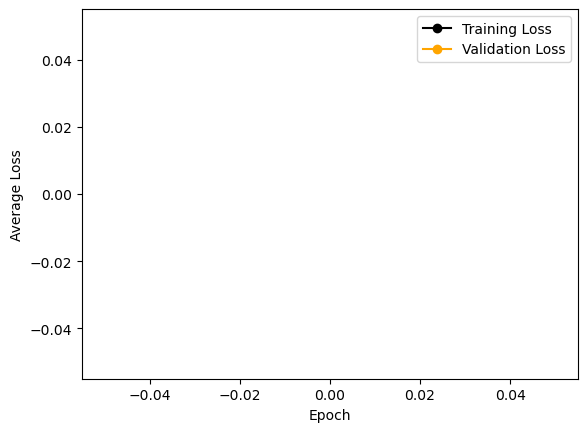

In [62]:
# Plotting,
epochs = np.arange(start=1, stop=len(train_losses)+1, step=1)
plt.plot(epochs, train_losses, marker="o", color="black", label="Training Loss")
plt.plot(epochs, val_losses, marker="o", color="orange", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.legend()
plt.show()

### 5. Model Training (PHASE 2)

Now we use L-BFGS for the fine-tuning phase,

### 6. Model Prediction

Let us create a function for model inference,

In [132]:
def predict(model, dataloader, device="cpu"):
    """This function performs model inference."""

    # Switch model to evaluation mode,
    model.eval()

    # Creating the predictions array,
    y_preds = []

    # Looping over all batches,
    with torch.no_grad():
        for X in dataloader:

            # Moving input tensor to training device,
            X = X.to(device).float()
    
            # Model forward pass,
            y_pred = model(X)
            y_pred = y_pred.cpu() # <-- Move to CPU.
            y_preds.append(y_pred)

    # Concatening batch predictions,
    y_preds = torch.cat(y_preds, dim=0)

    # Returning predictions,
    return y_preds

Now we generate the model predictions (remember that we work with Tensors and not NumPy arrays),

In [141]:
# Loading the required simulation data,
with h5py.File("cylinder_Re100.h5", "r") as file:
    t = torch.from_numpy(file["t"][:]).float()
    x = torch.from_numpy(file["x"][:]).float()
    y = torch.from_numpy(file["y"][:]).float()

X = torch.stack([
    x.reshape(-1),
    y.reshape(-1),
    torch.repeat_interleave(t, x.shape[1])
], dim=1)

# Scaling the simulation data,
X_scaled = (X - scaler.X_mins)/(scaler.X_maxs - scaler.X_mins + scaler.epsilon)

# Creating dataloader,
sim_loader = DataLoader(X_scaled, batch_size=BATCH_SIZE, shuffle=False)

# Generating model predictions,
y_pred = predict(model, dataloader=sim_loader, device="cpu")

# Reversing the scaling on the predictions,
y_pred = y_pred*(scaler.y_maxs - scaler.y_mins + scaler.epsilon) + scaler.y_mins

Now we have to convert our predictions `y_pred` from a Tensor to NumPy arrays that represent the predicted velocity and pressure fields. We must ensure that their shapes are consistent with the original simulation data such that we can use them in the simulation suite. 

In [142]:
# Converting to correct format,
n_time_steps, n_nodes = 201,  82872
y_pred = y_pred.numpy()
y_pred = y_pred.reshape(n_time_steps, n_nodes, 3) # Reshaping.
u_pred, v_pred, p_pred = y_pred[:, :, 0], y_pred[:, :, 1], y_pred[:, :, 2] # Extracting predicted fields.

# Saving predictions,
np.save(file="u_pred_baseline.npy", arr=u_pred)
np.save(file="v_pred_baseline", arr=v_pred)
np.save(file="p_pred_baseline", arr=p_pred)